In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

print("all the modules imported successfully")

all the modules imported successfully


In [5]:
df=pd.read_csv("C:\\Users\\User\\Downloads\\chicago_taxi_train.csv")

In [6]:
df.head()

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [7]:
columns_to_keep=['TRIP_SECONDS','TRIP_MILES','FARE','TIP_RATE','PAYMENT_TYPE','COMPANY']

In [8]:
df=df[columns_to_keep]

In [9]:
print(df)

       TRIP_SECONDS  TRIP_MILES   FARE  TIP_RATE PAYMENT_TYPE  \
0              2341        2.57  31.99       6.3       Mobile   
1              1074        1.18   9.75      27.9  Credit Card   
2              1173        1.29  10.25       0.0         Cash   
3              3360        3.70  23.75       0.0         Cash   
4              1044        1.15  10.00       0.0         Cash   
...             ...         ...    ...       ...          ...   
31689           739       13.06  32.50       0.0       Prcard   
31690          1740       30.90  44.50      13.9  Credit Card   
31691           687       12.21  30.75       0.0       Prcard   
31692          2040       36.60  41.75      25.2  Credit Card   
31693          2040       36.70  47.25       9.6  Credit Card   

                             COMPANY  
0                          Flash Cab  
1                          Flash Cab  
2                           Sun Taxi  
3            Choice Taxi Association  
4                       

In [10]:
print(df.shape)

(31694, 6)


In [11]:
print("dataset_statistic")

print(df.describe(include='all'))

dataset_statistic
        TRIP_SECONDS    TRIP_MILES          FARE      TIP_RATE PAYMENT_TYPE  \
count   31694.000000  31694.000000  31694.000000  31694.000000        31694   
unique           NaN           NaN           NaN           NaN            7   
top              NaN           NaN           NaN           NaN  Credit Card   
freq             NaN           NaN           NaN           NaN        14142   
mean     1319.796397      8.289463     23.905210     12.965785          NaN   
std       928.932873      7.265672     16.970022     15.517765          NaN   
min        60.000000      0.500000      3.250000      0.000000          NaN   
25%       548.000000      1.720000      9.000000      0.000000          NaN   
50%      1081.000000      5.920000     18.750000     12.200000          NaN   
75%      1888.000000     14.500000     38.750000     20.800000          NaN   
max      7140.000000     68.120000    159.250000    648.600000          NaN   

          COMPANY  
count       3

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_SECONDS  31694 non-null  int64  
 1   TRIP_MILES    31694 non-null  float64
 2   FARE          31694 non-null  float64
 3   TIP_RATE      31694 non-null  float64
 4   PAYMENT_TYPE  31694 non-null  object 
 5   COMPANY       31694 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 1.5+ MB


In [16]:
columns_to_keep1=['FARE','TRIP_MILES','TRIP_SECONDS']
df=df[columns_to_keep1]
correlation_matrix=df.corr()

print(correlation_matrix)

fare_correlations = correlation_matrix['FARE'].sort_values(ascending=False)
print(fare_correlations)

                  FARE  TRIP_MILES  TRIP_SECONDS
FARE          1.000000    0.975344      0.830292
TRIP_MILES    0.975344    1.000000      0.800855
TRIP_SECONDS  0.830292    0.800855      1.000000
FARE            1.000000
TRIP_MILES      0.975344
TRIP_SECONDS    0.830292
Name: FARE, dtype: float64


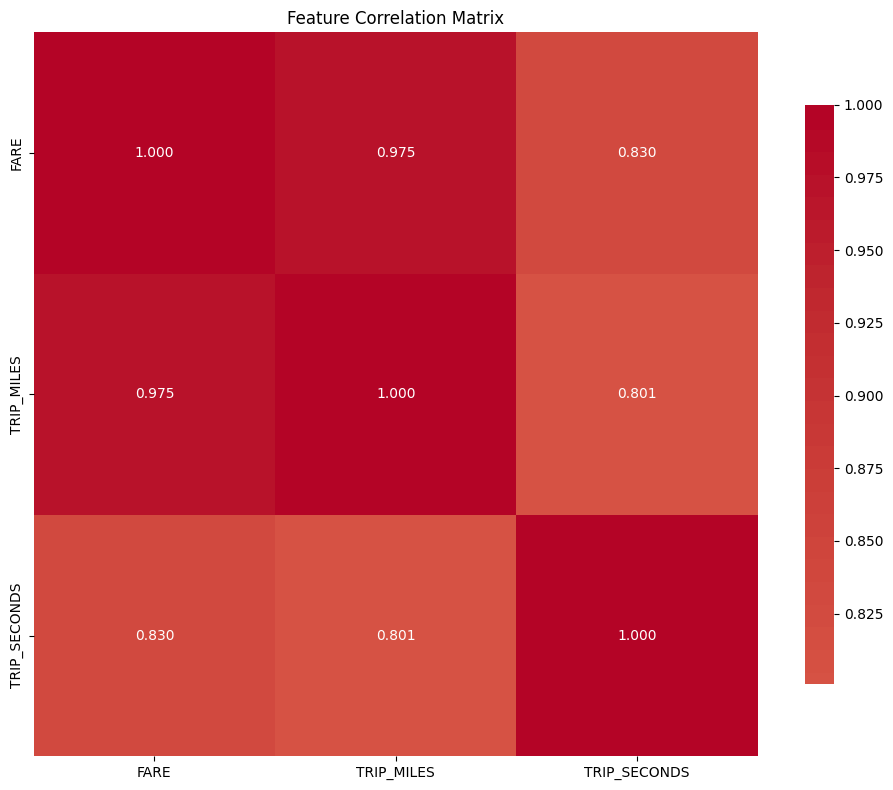

In [18]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()




In [24]:
import sklearn

In [25]:
from sklearn.linear_model import  LinearRegression 

from sklearn.metrics import mean_squared_error,r2_score

from sklearn.model_selection import train_test_split


def create_and_train_sklearn_model(df,features,target):
    X=df[features]
    Y=df[target]

    xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=42)

    model=LinearRegression()
    model.fit(xtrain,ytrain)

    y_pred=model.predict(xtest)

    mse=mean_squared_error(ytest,y_pred)
    r2=r2_score(ytest,y_pred)

    print(f"Mean Squared Error: {mse:.2f}")
    print(f"r2 score:{r2:.2f}")

    print(f"Coefficients: {dict(zip(features, model.coef_))}")
    print(f"Intercept: {model.intercept_:.2f}")

     
    return model, y_pred
    

features = ['TRIP_MILES', 'TRIP_SECONDS']
target = 'FARE'

model, predictions = create_and_train_sklearn_model(df, features, target)


Mean Squared Error: 12.99
r2 score:0.96
Coefficients: {'TRIP_MILES': np.float64(2.0163424402218975), 'TRIP_SECONDS': np.float64(0.002518164709808555)}
Intercept: 3.86


In [30]:
def calculate_fare(miles,seconds):
    base_Fare=3.86
    distance_Fare=miles*2.16
    time_fare=seconds*0.0015
    total_fare=base_Fare+distance_Fare+time_fare
    print(f"you have to pay ${total_fare} for the distance {miles} miles covered in {seconds} seconds")

calculate_fare(5,1500)
    

you have to pay $16.91 for the distance 5 miles covered in 1500 seconds


In [32]:
# STEP 1 IMPORT ALL THE LIBRARIES YOU WANT TO USE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("all the modules have been imported successfully")

all the modules have been imported successfully


In [35]:
# STEP 2 IMPORT THE DATASET YOU WANT YOUR MODEL TO TRAIN WITH

df=pd.read_csv("C:\\Users\\User\\Downloads\\chicago_taxi_train.csv")

In [36]:
# STEP 3  UPDATE THE DATA WITH COLUMNS YOU WANT TO TRAIN YOUR MODEL WITH OR SELECT 
# THE COLUMNS

print(df.shape)

(31694, 18)


In [39]:
print(df.head())

    TRIP_START_TIMESTAMP     TRIP_END_TIMESTAMP  TRIP_START_HOUR  \
0  05/17/2022 7:15:00 AM  05/17/2022 7:45:00 AM             7.25   
1  05/17/2022 5:15:00 PM  05/17/2022 5:30:00 PM            17.25   
2  05/17/2022 5:15:00 PM  05/17/2022 5:30:00 PM            17.25   
3  05/17/2022 6:00:00 PM  05/17/2022 7:00:00 PM            18.00   
4  05/17/2022 5:00:00 PM  05/17/2022 5:30:00 PM            17.00   

   TRIP_SECONDS  TRIP_MILES  TRIP_SPEED  PICKUP_CENSUS_TRACT  \
0          2341        2.57         4.0                  NaN   
1          1074        1.18         4.0                  NaN   
2          1173        1.29         4.0         1.703132e+10   
3          3360        3.70         4.0         1.703132e+10   
4          1044        1.15         4.0         1.703132e+10   

   DROPOFF_CENSUS_TRACT  PICKUP_COMMUNITY_AREA  DROPOFF_COMMUNITY_AREA   FARE  \
0                   NaN                    NaN                    17.0  31.99   
1          1.703108e+10                    N

In [40]:
columns_to_keep=['TRIP_SECONDS','TRIP_MILES','COMPANY','PAYMENT_TYPE','TIP_RATE','FARE']

In [41]:
df=df[columns_to_keep]

In [43]:
print(df.shape)

(31694, 6)


In [49]:
# step 3 EXPLORE YOUR DATASET CHECK SOME IMPORTANT THINGS

print(df.describe(include='all'))

        TRIP_SECONDS    TRIP_MILES    COMPANY PAYMENT_TYPE      TIP_RATE  \
count   31694.000000  31694.000000      31694        31694  31694.000000   
unique           NaN           NaN         31            7           NaN   
top              NaN           NaN  Flash Cab  Credit Card           NaN   
freq             NaN           NaN       7887        14142           NaN   
mean     1319.796397      8.289463        NaN          NaN     12.965785   
std       928.932873      7.265672        NaN          NaN     15.517765   
min        60.000000      0.500000        NaN          NaN      0.000000   
25%       548.000000      1.720000        NaN          NaN      0.000000   
50%      1081.000000      5.920000        NaN          NaN     12.200000   
75%      1888.000000     14.500000        NaN          NaN     20.800000   
max      7140.000000     68.120000        NaN          NaN    648.600000   

                FARE  
count   31694.000000  
unique           NaN  
top              N

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_SECONDS  31694 non-null  int64  
 1   TRIP_MILES    31694 non-null  float64
 2   COMPANY       31694 non-null  object 
 3   PAYMENT_TYPE  31694 non-null  object 
 4   TIP_RATE      31694 non-null  float64
 5   FARE          31694 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.5+ MB


In [51]:
# check for correlations  

columns=['TRIP_SECONDS','TRIP_MILES','TIP_RATE','FARE']

df=df[columns]

In [52]:
print(df.corr())

              TRIP_SECONDS  TRIP_MILES  TIP_RATE      FARE
TRIP_SECONDS      1.000000    0.800855 -0.084294  0.830292
TRIP_MILES        0.800855    1.000000 -0.049594  0.975344
TIP_RATE         -0.084294   -0.049594  1.000000 -0.070979
FARE              0.830292    0.975344 -0.070979  1.000000


In [55]:
# step 5 CREATE AND TRAIN YOUR MODEL

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split


In [58]:
def create_and_train_model(df,features,target):

    # prepare data

    X=df[features]
    Y=df[target]

    # split data

    xtrain,xtest,ytrain,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


    # Create and train model

    model=LinearRegression()
    model.fit(xtrain,ytrain)

    # make predictions

    y_pred=model.predict(xtest)

    # Evalute

    mse=mean_squared_error(y_test, y_pred)
    r2=r2_score(y_test,y_pred)


       
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"Coefficients: {dict(zip(features, model.coef_))}")
    print(f"Intercept: {model.intercept_:.2f}")
    
    return model, y_pred

    
features=['TRIP_SECONDS','TRIP_MILES','TIP_RATE']
target='FARE'
create_and_train_model(df,features,target)

Mean Squared Error: 12.91
R² Score: 0.96
Coefficients: {'TRIP_SECONDS': np.float64(0.0024808755301822085), 'TRIP_MILES': np.float64(2.018273464322237), 'TIP_RATE': np.float64(-0.017989827028327632)}
Intercept: 4.12


(LinearRegression(),
 array([15.80882514,  4.95946597, 33.61749467, ..., 47.85210163,
         5.57917738, 17.13668926], shape=(6339,)))

In [6]:
def calculate_fare(miles,seconds,tip):
    base_Fare=4.12
    distance_Fare=miles*2.018
    time_fare=seconds*0.0024
    tip_fare=tip*(-0.017)
    total_fare=base_Fare+distance_Fare+time_fare
    print(f"you have to pay ${total_fare} for the distance {miles} miles covered in {seconds} seconds")

calculate_fare(7,1200,0.6)

you have to pay $21.125999999999998 for the distance 7 miles covered in 1200 seconds
